# Contexto e Objetivo
Este relatório detalha a investigação realizada pela equipe de *Trust & Safety* para desarticular um esquema de manipulação de avaliações e vendas fraudulentas. A suspeita é que um grupo de vendedores esteja simulando transações em horários atípicos e utilizando contas falsas (*shilling*) para inflar artificialmente sua reputação na plataforma.

**Nossa missão é:**
1. Identificar padrões de horários anômalos.
2. Rastrear avaliações falsas via IP e tempo de conta.
3. Mensurar o impacto financeiro da fraude.
4. Propor um Score de Risco para detecção automática.

## Importação de Dependências e Configurações

In [71]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scripts.outliers import outlier_iqr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}') # Com separador de milhar

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

## Análise inicial dos arquivos

In [72]:
df_vendas = pd.read_csv('..\\data\\projeto_02_ecommerce_vendas.csv')
df_vendedor = pd.read_csv('..\\data\\projeto_02_vendedores_perfil.csv')
df_aval_sus = pd.read_csv('..\\data\\projeto_02_avaliacoes_suspeitas.csv')

In [73]:
print('Informações Iniciais dos DataFrames -- Vendas')
print('--'*100)
print(df_vendas.info(), end='\n\n\n')

Informações Iniciais dos DataFrames -- Vendas
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pedido_id       8000 non-null   str    
 1   data_pedido     8000 non-null   str    
 2   hora_pedido     8000 non-null   str    
 3   vendedor_id     8000 non-null   str    
 4   categoria       8000 non-null   str    
 5   produto_id      8000 non-null   str    
 6   preco_unitario  8000 non-null   float64
 7   quantidade      8000 non-null   int64  
 8   valor_total     8000 non-null   float64
 9   frete           7767 non-null   float64
 10  estado_cliente  8000 non-null   str    
 11  status_pedido   8000 non-null   str    
 12  nota_avaliacao  5023 n

In [74]:
print('Informações Iniciais dos DataFrames -- Vendedores')
print('--'*100)
print(df_vendedor.info())

Informações Iniciais dos DataFrames -- Vendedores
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vendedor_id          120 non-null    str    
 1   nome_loja            120 non-null    str    
 2   data_cadastro        120 non-null    str    
 3   cidade               120 non-null    str    
 4   estado               120 non-null    str    
 5   categoria_principal  120 non-null    str    
 6   total_vendas         120 non-null    int64  
 7   nota_media_loja      120 non-null    float64
 8   reclamacoes          120 non-null    int64  
 9   verificado           120 non-null    bool   
dtypes: bool(1), float64(1), int64(2), str(6)
memory us

In [75]:
print('Informações Iniciais dos DataFrames -- Avaliações Suspeitas')
print('--'*100)
print(df_aval_sus.info())

Informações Iniciais dos DataFrames -- Avaliações Suspeitas
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   avaliacao_id        3000 non-null   str  
 1   vendedor_id         3000 non-null   str  
 2   comprador_id        3000 non-null   str  
 3   data_avaliacao      3000 non-null   str  
 4   data_criacao_conta  3000 non-null   str  
 5   nota                3000 non-null   int64
 6   ip_origem           3000 non-null   str  
 7   texto_avaliacao     2668 non-null   str  
dtypes: int64(1), str(7)
memory usage: 187.6 KB
None


## Preparação dos Dados (Data Cleaning)
- Nesta etapa, realizamos o tratamento da coluna `preco_unitario`, que apresenta inconsistências de tipo (strings com símbolos de moeda). 
- Também padronizamos as colunas de data e hora para permitir a análise temporal, essencial para identificar o comportamento dos vendedores durante a madrugada.

In [76]:
for col in df_vendas.columns:
    print(col)
    print(np.sort(df_vendas[col].unique().tolist()))
    print('\n\n')

pedido_id
['PED-000001' 'PED-000002' 'PED-000003' ... 'PED-007998' 'PED-007999'
 'PED-008000']



data_pedido
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05'
 '2023-01-06' '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10'
 '2023-01-11' '2023-01-12' '2023-01-13' '2023-01-14' '2023-01-15'
 '2023-01-16' '2023-01-17' '2023-01-18' '2023-01-19' '2023-01-20'
 '2023-01-21' '2023-01-22' '2023-01-23' '2023-01-24' '2023-01-25'
 '2023-01-26' '2023-01-27' '2023-01-28' '2023-01-29' '2023-01-30'
 '2023-01-31' '2023-02-01' '2023-02-02' '2023-02-03' '2023-02-04'
 '2023-02-05' '2023-02-06' '2023-02-07' '2023-02-08' '2023-02-09'
 '2023-02-10' '2023-02-11' '2023-02-12' '2023-02-13' '2023-02-14'
 '2023-02-15' '2023-02-16' '2023-02-17' '2023-02-18' '2023-02-19'
 '2023-02-20' '2023-02-21' '2023-02-22' '2023-02-23' '2023-02-24'
 '2023-02-25' '2023-02-26' '2023-02-27' '2023-02-28' '2023-03-01'
 '2023-03-02' '2023-03-03' '2023-03-04' '2023-03-05' '2023-03-06'
 '2023-03-07' '2023-03-08' '2023

In [77]:
df_vendas['_data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendas['_data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendas['_hora_pedido_dt'] = pd.to_datetime(df_vendas['hora_pedido'], format='%H:%M')
df_vendas['frete'] = pd.to_numeric(df_vendas['frete']).fillna(0)
df_vendas['nota_avaliacao'] = df_vendas['nota_avaliacao'].fillna(0)

In [78]:
for col in df_vendedor.columns:
    print(col)
    print(np.sort(df_vendedor[col].unique()))
    print('\n\n')

vendedor_id
['VEND-0001' 'VEND-0002' 'VEND-0003' 'VEND-0004' 'VEND-0005' 'VEND-0006'
 'VEND-0007' 'VEND-0008' 'VEND-0009' 'VEND-0010' 'VEND-0011' 'VEND-0012'
 'VEND-0013' 'VEND-0014' 'VEND-0015' 'VEND-0016' 'VEND-0017' 'VEND-0018'
 'VEND-0019' 'VEND-0020' 'VEND-0021' 'VEND-0022' 'VEND-0023' 'VEND-0024'
 'VEND-0025' 'VEND-0026' 'VEND-0027' 'VEND-0028' 'VEND-0029' 'VEND-0030'
 'VEND-0031' 'VEND-0032' 'VEND-0033' 'VEND-0034' 'VEND-0035' 'VEND-0036'
 'VEND-0037' 'VEND-0038' 'VEND-0039' 'VEND-0040' 'VEND-0041' 'VEND-0042'
 'VEND-0043' 'VEND-0044' 'VEND-0045' 'VEND-0046' 'VEND-0047' 'VEND-0048'
 'VEND-0049' 'VEND-0050' 'VEND-0051' 'VEND-0052' 'VEND-0053' 'VEND-0054'
 'VEND-0055' 'VEND-0056' 'VEND-0057' 'VEND-0058' 'VEND-0059' 'VEND-0060'
 'VEND-0061' 'VEND-0062' 'VEND-0063' 'VEND-0064' 'VEND-0065' 'VEND-0066'
 'VEND-0067' 'VEND-0068' 'VEND-0069' 'VEND-0070' 'VEND-0071' 'VEND-0072'
 'VEND-0073' 'VEND-0074' 'VEND-0075' 'VEND-0076' 'VEND-0077' 'VEND-0078'
 'VEND-0079' 'VEND-0080' 'VEND-0081' 'V

In [79]:
df_vendedor['_data_cadastro_dt'] = pd.to_datetime(
    df_vendedor['data_cadastro'],  format='%Y-%m-%d')

In [80]:
for col in df_aval_sus.columns:
    print(col)
    if col != "texto_avaliacao":
        print(np.sort(df_aval_sus[col].unique()))
    else:
        print(df_aval_sus[col].drop_duplicates().sort_values())
    print('\n\n')

avaliacao_id
['AVAL-00001' 'AVAL-00002' 'AVAL-00003' ... 'AVAL-02998' 'AVAL-02999'
 'AVAL-03000']



vendedor_id
['VEND-0001' 'VEND-0002' 'VEND-0003' 'VEND-0004' 'VEND-0005' 'VEND-0006'
 'VEND-0007' 'VEND-0008' 'VEND-0009' 'VEND-0010' 'VEND-0011' 'VEND-0012'
 'VEND-0013' 'VEND-0014' 'VEND-0015' 'VEND-0016' 'VEND-0017' 'VEND-0018'
 'VEND-0019' 'VEND-0020' 'VEND-0021' 'VEND-0022' 'VEND-0023' 'VEND-0024'
 'VEND-0025' 'VEND-0026' 'VEND-0027' 'VEND-0028' 'VEND-0029' 'VEND-0030'
 'VEND-0031' 'VEND-0032' 'VEND-0033' 'VEND-0034' 'VEND-0035' 'VEND-0036'
 'VEND-0037' 'VEND-0038' 'VEND-0039' 'VEND-0040' 'VEND-0041' 'VEND-0042'
 'VEND-0043' 'VEND-0044' 'VEND-0045' 'VEND-0046' 'VEND-0047' 'VEND-0048'
 'VEND-0049' 'VEND-0050' 'VEND-0051' 'VEND-0052' 'VEND-0053' 'VEND-0054'
 'VEND-0055' 'VEND-0056' 'VEND-0057' 'VEND-0058' 'VEND-0059' 'VEND-0060'
 'VEND-0061' 'VEND-0062' 'VEND-0063' 'VEND-0064' 'VEND-0065' 'VEND-0066'
 'VEND-0067' 'VEND-0068' 'VEND-0069' 'VEND-0070' 'VEND-0071' 'VEND-0072'
 'VEND-0073

In [81]:
df_aval_sus['_data_avaliacao_dt'] = pd.to_datetime(
    df_aval_sus['data_avaliacao'], format='%Y-%m-%d')

df_aval_sus['_data_criacao_conta_dt'] = pd.to_datetime(
    df_aval_sus['data_criacao_conta'], format='%Y-%m-%d')

df_aval_sus['texto_avaliacao'] = df_aval_sus['texto_avaliacao'].fillna(
    'Sem Comentário Escrito')

## Detecção de duplicatas

In [82]:
dup_vendas_pedido = df_vendas.duplicated(subset=['pedido_id']).sum()
dup_vendas_item = df_vendas.duplicated(subset=['pedido_id', 'produto_id']).sum()
print('VENDAS')
print(f'  Linhas duplicadas por pedido_id: {dup_vendas_pedido}')
print(f'  Linhas duplicadas por (pedido_id, produto_id): {dup_vendas_item}')
if dup_vendas_item > 0:
    n_antes = len(df_vendas)
    df_vendas = df_vendas.drop_duplicates(subset=['pedido_id', 'produto_id'], keep='first')
    print(f'  -> Removidas {n_antes - len(df_vendas)} duplicatas. Total de linhas: {len(df_vendas)}')

VENDAS
  Linhas duplicadas por pedido_id: 0
  Linhas duplicadas por (pedido_id, produto_id): 0


In [83]:
dup_vendedor = df_vendedor.duplicated(subset=['vendedor_id']).sum()
print('VENDEDORES')
print(f'  Linhas duplicadas por vendedor_id: {dup_vendedor}')
if dup_vendedor > 0:
    n_antes = len(df_vendedor)
    df_vendedor = df_vendedor.drop_duplicates(subset=['vendedor_id'], keep='first')
    print(f'  -> Removidas {n_antes - len(df_vendedor)} duplicatas. Total de linhas: {len(df_vendedor)}')

VENDEDORES
  Linhas duplicadas por vendedor_id: 0


In [84]:
dup_aval_id = df_aval_sus.duplicated(subset=['avaliacao_id']).sum()
dup_aval_multi = df_aval_sus.duplicated(subset=['vendedor_id', 'comprador_id', 'data_avaliacao']).sum()
print('AVALIAÇÕES SUSPEITAS')
print(f'  Linhas duplicadas por avaliacao_id: {dup_aval_id}')
print(f'  Linhas duplicadas por (vendedor_id, comprador_id, data_avaliacao): {dup_aval_multi}')
if dup_aval_id > 0:
    n_antes = len(df_aval_sus)
    df_aval_sus = df_aval_sus.drop_duplicates(subset=['avaliacao_id'], keep='first')
    print(f'  -> Removidas {n_antes - len(df_aval_sus)} duplicatas por avaliacao_id. Total de linhas: {len(df_aval_sus)}')

AVALIAÇÕES SUSPEITAS
  Linhas duplicadas por avaliacao_id: 0
  Linhas duplicadas por (vendedor_id, comprador_id, data_avaliacao): 0


## Investigações base

---
### **Distribuição entre tipos de vendedores: Verificados e Não Verificados**

In [85]:
df_vendedor['verificado'].value_counts(normalize='percent')

verificado
False   0.53
True    0.47
Name: proportion, dtype: float64

In [86]:
verificados = df_vendedor.query('verificado == True')
n_verificados = df_vendedor.query('verificado == False')

print('Verificados:')
print(verificados['vendedor_id'].unique())
print('---'*100)

print('Não Verificados:')
print(n_verificados['vendedor_id'].unique())

Verificados:
<StringArray>
['VEND-0003', 'VEND-0006', 'VEND-0007', 'VEND-0009', 'VEND-0010', 'VEND-0015',
 'VEND-0016', 'VEND-0018', 'VEND-0019', 'VEND-0020', 'VEND-0022', 'VEND-0025',
 'VEND-0026', 'VEND-0027', 'VEND-0028', 'VEND-0029', 'VEND-0032', 'VEND-0041',
 'VEND-0047', 'VEND-0049', 'VEND-0050', 'VEND-0051', 'VEND-0053', 'VEND-0054',
 'VEND-0055', 'VEND-0057', 'VEND-0058', 'VEND-0059', 'VEND-0060', 'VEND-0062',
 'VEND-0063', 'VEND-0064', 'VEND-0065', 'VEND-0067', 'VEND-0071', 'VEND-0072',
 'VEND-0073', 'VEND-0074', 'VEND-0075', 'VEND-0077', 'VEND-0084', 'VEND-0085',
 'VEND-0086', 'VEND-0091', 'VEND-0092', 'VEND-0096', 'VEND-0098', 'VEND-0100',
 'VEND-0103', 'VEND-0107', 'VEND-0108', 'VEND-0109', 'VEND-0111', 'VEND-0112',
 'VEND-0116', 'VEND-0117', 'VEND-0118']
Length: 57, dtype: str
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**Conclusão**: Não há uma sobreposição muito significativa da quantidade de `verificados` e `não verificados` e não há repetição de `vendedor_id` em categorias distintas

### **Verificação de vendas**

In [87]:
df_vendas_merged = df_vendas.merge(df_vendedor[['vendedor_id', 'verificado']], on='vendedor_id')
df_vendas_merged

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,_data_pedido_dt,_hora_pedido_dt,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.00,2024-04-14,1900-01-01 11:56:00,False
1,PED-000002,2024-08-08,12:19,VEND-0021,Moda Feminina,PROD-0080,83.45,1,83.45,37.69,BA,Devolvido,0.00,2024-08-08,1900-01-01 12:19:00,False
2,PED-000003,2023-10-21,16:01,VEND-0004,Eletrônicos,PROD-0227,447.89,1,447.89,40.15,PE,Em trânsito,0.00,2023-10-21,1900-01-01 16:01:00,False
3,PED-000004,2023-10-29,18:53,VEND-0083,Eletrônicos,PROD-0282,620.43,2,"1,240.86",10.89,MG,Entregue,5.00,2023-10-29,1900-01-01 18:53:00,False
4,PED-000005,2024-03-21,09:13,VEND-0025,Acessórios,PROD-0141,36.96,1,36.96,35.60,MA,Entregue,4.00,2024-03-21,1900-01-01 09:13:00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,PED-007996,2024-07-29,12:33,VEND-0058,Acessórios,PROD-0359,78.62,1,78.62,19.67,CE,Cancelado,0.00,2024-07-29,1900-01-01 12:33:00,True
7996,PED-007997,2024-04-11,06:56,VEND-0039,Moda Feminina,PROD-0025,121.46,3,364.38,40.36,PE,Entregue,3.00,2024-04-11,1900-01-01 06:56:00,False
7997,PED-007998,2023-06-01,19:37,VEND-0049,Casa & Decoração,PROD-0349,142.81,1,142.81,39.61,CE,Entregue,5.00,2023-06-01,1900-01-01 19:37:00,True
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,"1,337.26",39.09,SP,Em trânsito,0.00,2023-04-23,1900-01-01 10:34:00,False


In [88]:
valor_total_incorreto = df_vendas_merged[
    (df_vendas_merged['preco_unitario'] * df_vendas_merged['quantidade']) != df_vendas_merged['valor_total']
]

valor_total_incorreto['verificado'].value_counts(normalize=True)

verificado
False   0.54
True    0.46
Name: proportion, dtype: float64

**PONTO DE ATENÇÃO**: 

- Há casos em que o valor total da venda está incorreto e que o frete é desconsiderado do cálculo independente da presença do frete e independente do fato de ser verificado ou não.

- Verificar qual a razão por trás disso



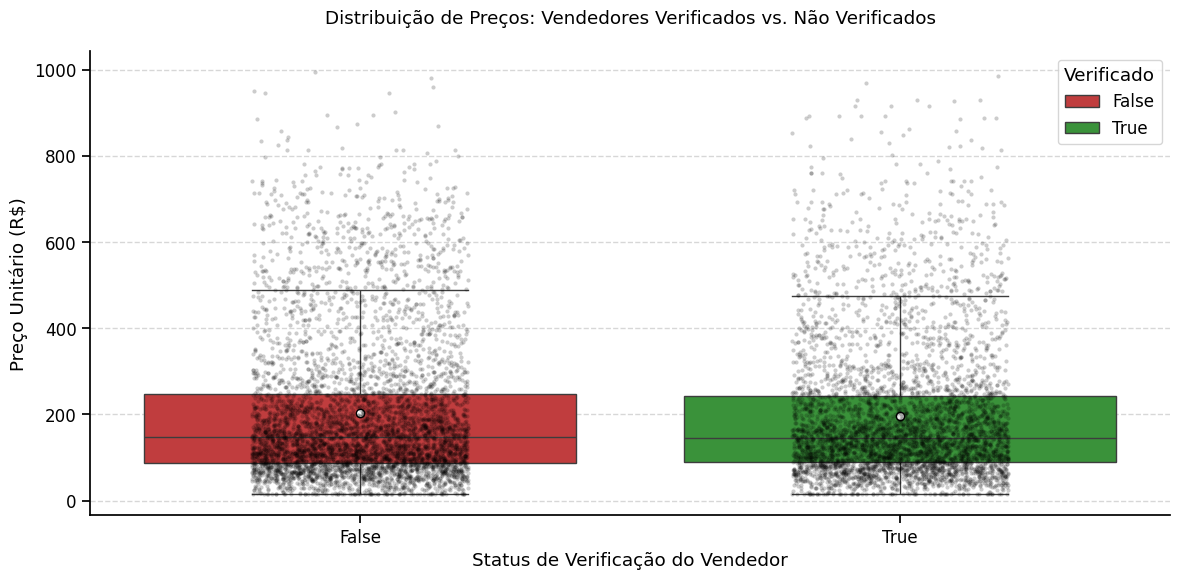

In [89]:
df_expandido = df_vendas_merged.loc[df_vendas_merged.index.repeat(df_vendas_merged['quantidade'])]

plt.figure(figsize=(12, 6))
sns.set_context("notebook", font_scale=1.1)

ax = sns.boxplot(
    data=df_expandido,
    x='verificado',
    y='preco_unitario',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_expandido, 
    x='verificado', 
    y='preco_unitario', 
    color='black', 
    alpha=0.2,
    jitter=0.2,
    size=3
)

plt.title('Distribuição de Preços: Vendedores Verificados vs. Não Verificados', pad=20)
plt.xlabel('Status de Verificação do Vendedor')
plt.ylabel('Preço Unitário (R$)')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Verificado', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

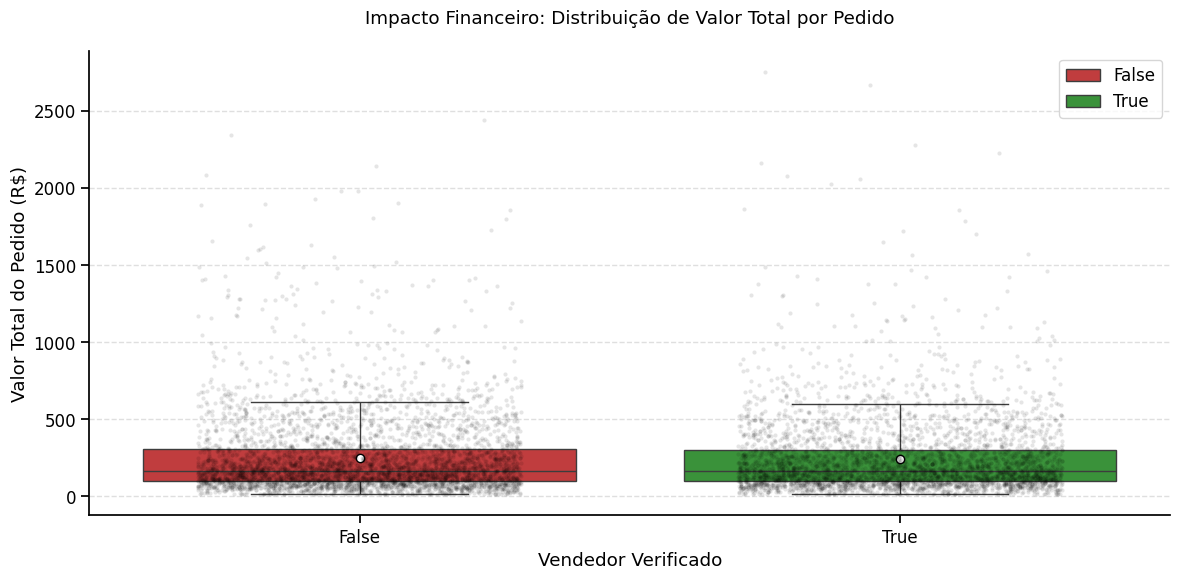

In [90]:
plt.figure(figsize=(12, 6))
sns.set_context("notebook", font_scale=1.1)

ax = sns.boxplot(
    data=df_vendas_merged,
    x='verificado',
    y='valor_total',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_vendas_merged, 
    x='verificado', 
    y='valor_total', 
    color='black', 
    alpha=0.1,
    jitter=0.3,
    size=3
)

plt.title('Impacto Financeiro: Distribuição de Valor Total por Pedido', pad=20)
plt.xlabel('Vendedor Verificado')
plt.ylabel('Valor Total do Pedido (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

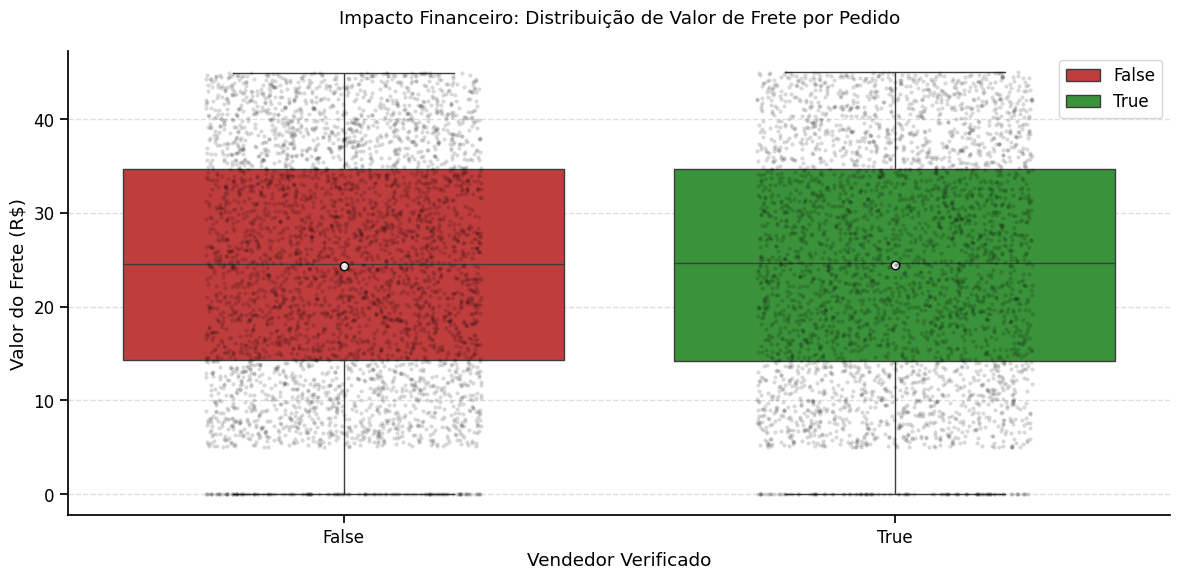

In [91]:
plt.figure(figsize=(12, 6))
sns.set_context("notebook", font_scale=1.1)

ax = sns.boxplot(
    data=df_vendas_merged,
    x='verificado',
    y='frete',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_vendas_merged, 
    x='verificado', 
    y='frete', 
    color='black', 
    alpha=0.15,
    jitter=0.25,
    size=3
)

plt.title('Impacto Financeiro: Distribuição de Valor de Frete por Pedido', pad=20)
plt.xlabel('Vendedor Verificado')
plt.ylabel('Valor do Frete (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

In [92]:
df_vendas_merged_clean_vt, outliers_vendas = outlier_iqr(df_vendas_merged, 'valor_total')
df_expandido_vt, outliers_expandido = outlier_iqr(df_expandido, 'preco_unitario')
df_vendas_merged_clean_frete, outliers_vendas = outlier_iqr(df_vendas_merged, 'frete')

Coluna: valor_total
Outliers removidos: 587
Limites: -207.35 a 608.93

Coluna: preco_unitario
Outliers removidos: 849
Limites: -149.40 a 483.82

Coluna: frete
Outliers removidos: 0
Limites: -16.23 a 65.24



In [93]:
estao_presentes = df_vendas_merged_clean_vt.index.isin(df_expandido_vt.index).all()

if estao_presentes:
    print("✅ Sucesso: Todos os registros do DF limpo estão no DF expandido.")
else:
    print("❌ Atenção: Alguns registros do DF limpo não foram encontrados no expandido.")

❌ Atenção: Alguns registros do DF limpo não foram encontrados no expandido.


In [94]:
ids_limpos = set(df_vendas_merged_clean_vt['pedido_id'])
ids_expandidos = set(df_expandido_vt['pedido_id'])

faltantes = ids_limpos - ids_expandidos

if not faltantes:
    print("✅ Todos os pedido_id estão presentes.")
else:
    print(f"❌ Faltam {len(faltantes)} pedidos no DataFrame expandido.")

❌ Faltam 308 pedidos no DataFrame expandido.


In [95]:
indices_outliers_vt = outliers_vendas.index
indices_outliers_pu = outliers_expandido.index
todos_indices_para_remover = set(indices_outliers_vt).union(set(indices_outliers_pu))


df_vendas_merged_final = df_vendas_merged.drop(index=todos_indices_para_remover, errors='ignore')

df_expandido_final = df_expandido.drop(index=todos_indices_para_remover, errors='ignore')

indices_validos = set(df_vendas_merged_clean_vt.index) & \
                  set(df_vendas_merged_clean_frete.index)


indices_validos = indices_validos & set(df_expandido_vt.index)

indices_para_remover = df_vendas.index.difference(indices_validos)

df_vendas_final = df_vendas.drop(index=indices_para_remover)

print(f"Registros originais: {len(df_vendas)}")
print(f"Registros após remoção de outliers: {len(df_vendas_final)}")
print(f"Total de linhas removidas: {len(indices_para_remover)}")

Registros originais: 8000
Registros após remoção de outliers: 7105
Total de linhas removidas: 895


---
### 1. **Existem vendedores com padrão de vendas concentrado em horários atípicos** (madrugada, 2h-5h)? Quem são e qual o volume?
- Consumidores reais de e-commerce brasileiro tendem a comprar em horários comerciais e no início da noite. 
- Abaixo, filtramos as vendas ocorridas entre **2h e 5h da manhã**.
- O objetivo é identificar vendedores cujo volume de vendas nesse período seja estatisticamente desproporcional ao comportamento normal do mercado.

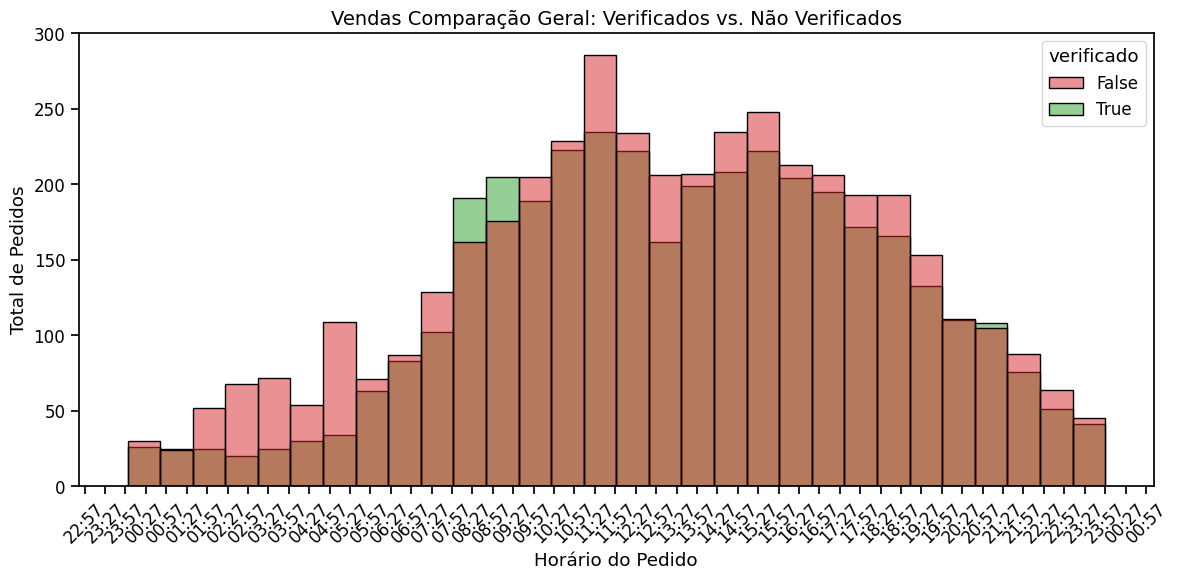

In [96]:
vendas_com_status_geral = df_vendas.merge(df_vendedor[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=vendas_com_status_geral, 
    x='_hora_pedido_dt', 
    hue='verificado', 
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer' 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title('Vendas Comparação Geral: Verificados vs. Não Verificados', fontsize=14)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

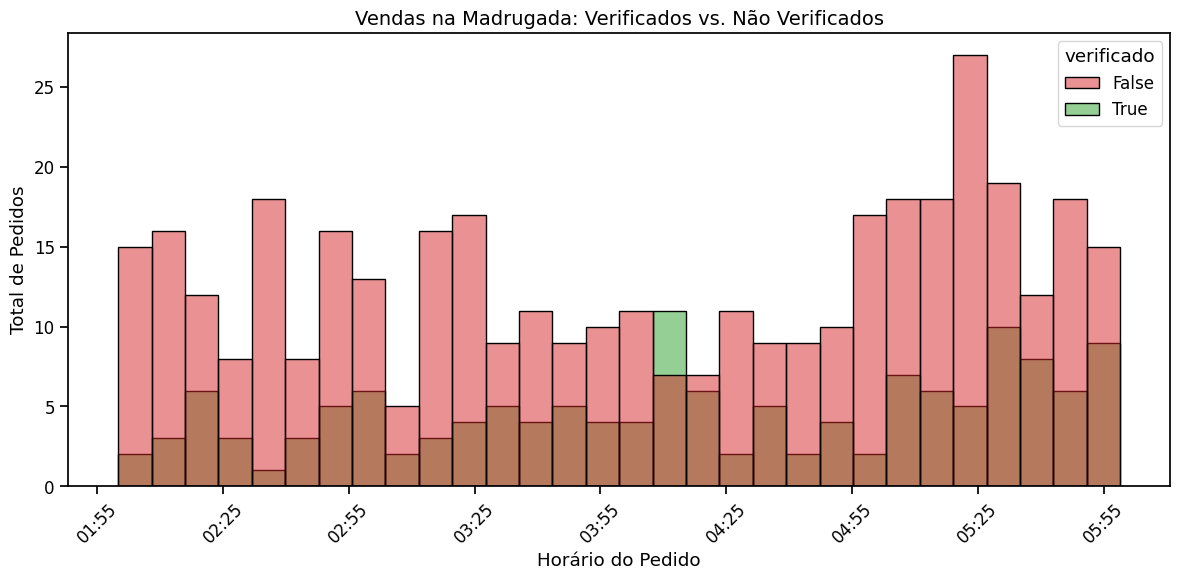

In [97]:
vendas_2_5_am = df_vendas.query('_hora_pedido_dt.dt.hour >= 2 and _hora_pedido_dt.dt.hour <= 5')
vendas_com_status = vendas_2_5_am.merge(df_vendedor[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=vendas_com_status, 
    x='_hora_pedido_dt', 
    hue='verificado', 
    palette={True: '#2ca02c', False: '#d62728'}, # Verde para Verificado, Vermelho para Não
    bins=30,
    multiple='layer' 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title('Vendas na Madrugada: Verificados vs. Não Verificados', fontsize=14)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

**Conclusões**
- Em comparação ao horário das 8:00 ao 12:00 é quase irrelevante, melhor esperar para ver novas informações.

- Ainda que seja visível que vendas dos não verificados é maior é melhor considerar como um ponto futuro de análise

---
### 2. **Há avaliações falsas?** Identifique padrões: contas criadas há poucos dias que avaliam com nota 5, IPs repetidos, textos idênticos.

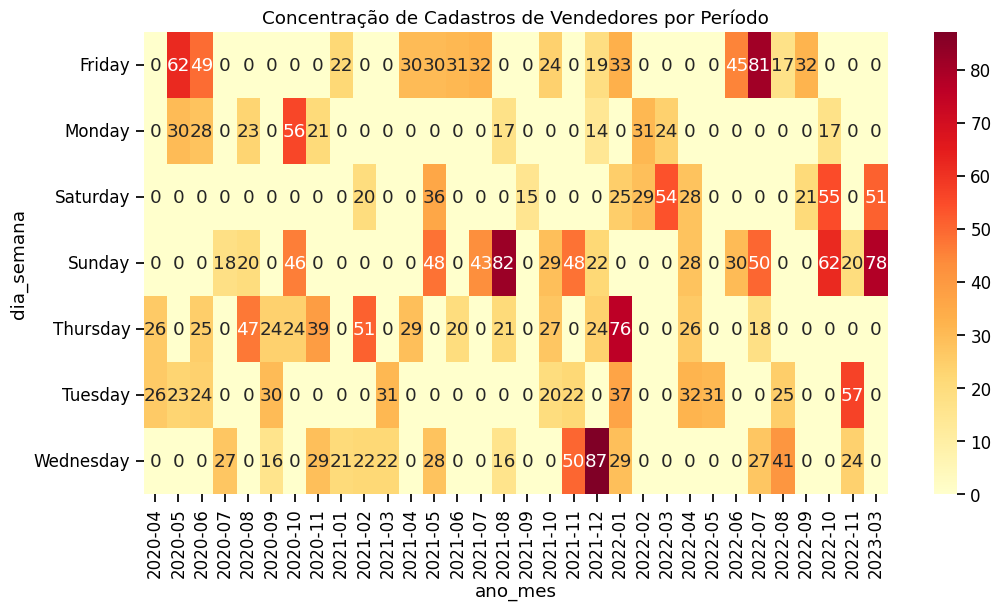

In [98]:
df_aval_sus['tempo_criacao_conta_dias'] = (df_aval_sus['_data_avaliacao_dt'] - df_aval_sus['_data_criacao_conta_dt']).dt.days
df_aval_sus_info = df_aval_sus.merge(df_vendedor, on='vendedor_id', how='left')
df_aval_sus_info['ano_mes'] = df_aval_sus_info['_data_cadastro_dt'].dt.to_period('M')
df_aval_sus_info['dia_semana'] = df_aval_sus_info['_data_cadastro_dt'].dt.day_name()

pivot_cluster = df_aval_sus_info.pivot_table(
    index='dia_semana', 
    columns='ano_mes', 
    values='vendedor_id', 
    aggfunc='count'
).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_cluster, annot=True, cmap='YlOrRd', fmt='g')
plt.title('Concentração de Cadastros de Vendedores por Período')
plt.show()
picos_mes = df_aval_sus_info.groupby('ano_mes').size()
meses_suspeitos = picos_mes[picos_mes > 50].index

In [99]:
df_aval_sus_info['is_cluster_cadastro'] = df_aval_sus_info['ano_mes'].isin(meses_suspeitos)
df_aval_sus_info[df_aval_sus_info['is_cluster_cadastro']]
df_aval_sus_info['tempo_criacao_conta_dias'].describe()

count   3,000.00
mean      366.73
std       208.72
min         1.00
25%       188.00
50%       365.00
75%       548.00
max       730.00
Name: tempo_criacao_conta_dias, dtype: float64

In [100]:
df_nota_5 = df_aval_sus_info.query('nota == 5')
df_nota_5.query('verificado == False')['tempo_criacao_conta_dias'].describe()

count   635.00
mean    329.24
std     229.78
min       1.00
25%     122.00
50%     317.00
75%     527.50
max     730.00
Name: tempo_criacao_conta_dias, dtype: float64

In [101]:
df_nota_5 = df_aval_sus_info.query('nota == 5')
df_nota_5.query('verificado == True')['tempo_criacao_conta_dias'].describe()

count   555.00
mean    383.20
std     201.50
min      31.00
25%     205.50
50%     375.00
75%     554.00
max     729.00
Name: tempo_criacao_conta_dias, dtype: float64

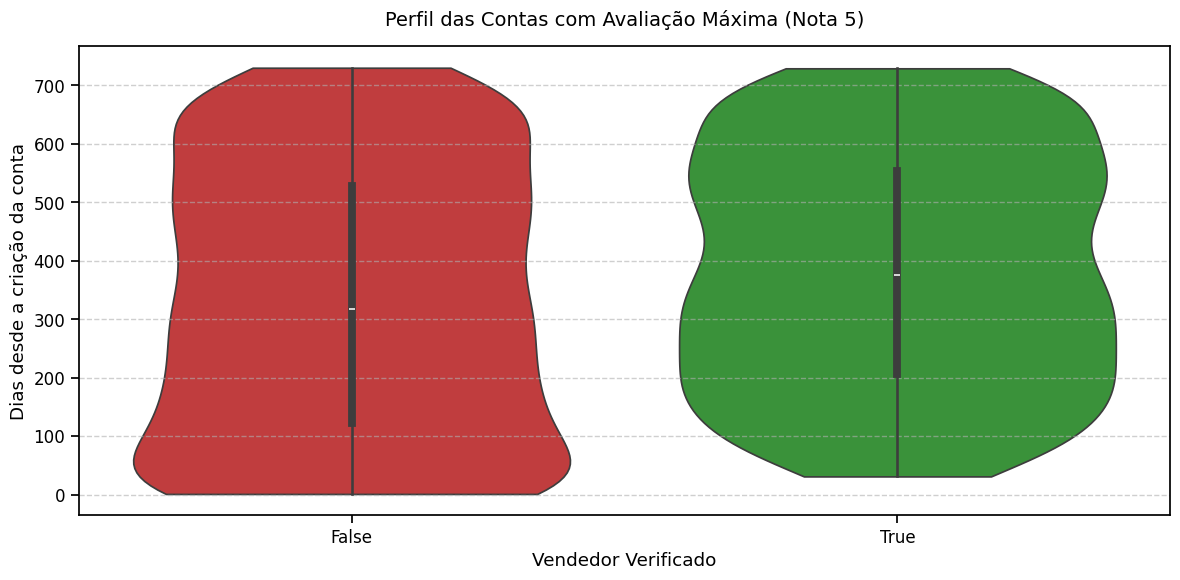

In [102]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_nota_5, 
    x='verificado',
    y='tempo_criacao_conta_dias', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylabel('Dias desde a criação da conta')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

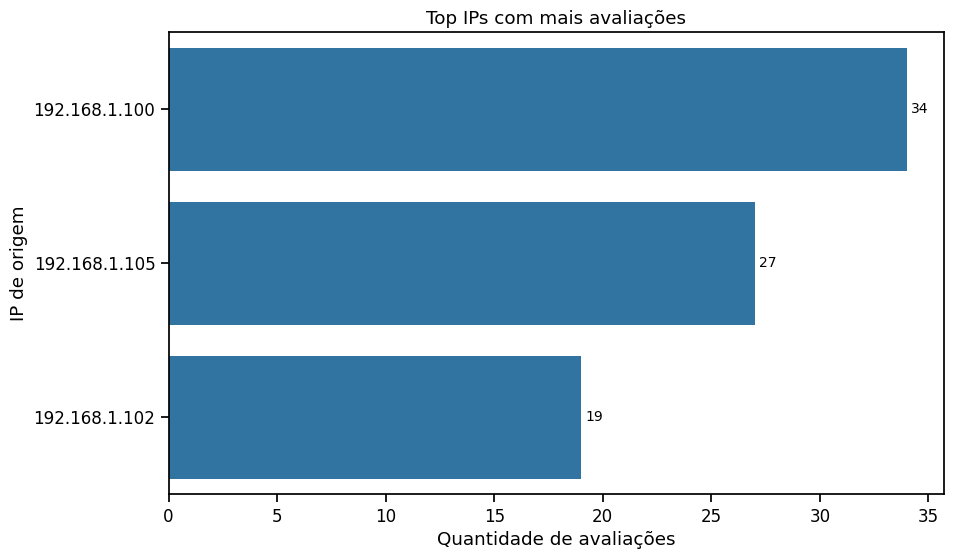

In [103]:
df_ips = df_nota_5.groupby(
    ['vendedor_id', 'verificado', 'ip_origem']
).size().reset_index(name='contagem_por_ip').sort_values('contagem_por_ip', ascending=False)


top_ips = df_ips.groupby('ip_origem')['contagem_por_ip'] \
    .sum() \
    .sort_values(ascending=False) \
    .reset_index()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_ips.query('contagem_por_ip > 1'),
    x='contagem_por_ip',
    y='ip_origem',
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Top IPs com mais avaliações')
plt.xlabel('Quantidade de avaliações')
plt.ylabel('IP de origem')

plt.show()

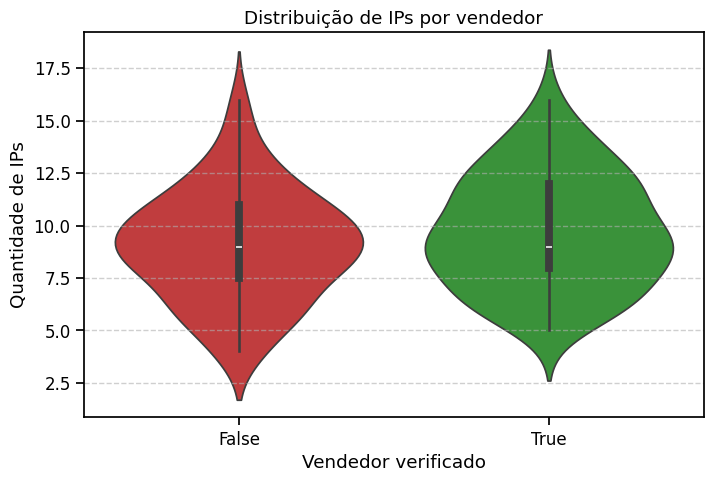

In [104]:
ips_por_vendedor = df_ips.groupby(
    ['vendedor_id','verificado']
)['ip_origem'].nunique().reset_index(name='qtd_ips')

plt.figure(figsize=(8,5))

sns.violinplot(
    data=ips_por_vendedor,
    x='verificado',
    y='qtd_ips',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    legend=False
)

plt.title('Distribuição de IPs por vendedor')
plt.xlabel('Vendedor verificado')
plt.ylabel('Quantidade de IPs')
plt.grid(axis='y', linestyle='--', alpha=0.6) # Ajuda a ler os dias exatos

plt.show()

In [105]:
ips_por_vendedor.query('verificado == True')['qtd_ips'].describe()

count   57.00
mean     9.74
std      2.68
min      5.00
25%      8.00
50%      9.00
75%     12.00
max     16.00
Name: qtd_ips, dtype: float64

In [106]:
ips_por_vendedor.query('verificado == False')['qtd_ips'].describe()

count   63.00
mean     9.05
std      2.64
min      4.00
25%      7.50
50%      9.00
75%     11.00
max     16.00
Name: qtd_ips, dtype: float64

In [107]:
vendedores_por_ip_nao_verificado = df_ips.query('verificado == False').groupby('ip_origem')['vendedor_id'] \
    .nunique() \
    .reset_index(name='qtd_vendedores')

ips_suspeitos = vendedores_por_ip_nao_verificado.sort_values(
    'qtd_vendedores',
    ascending=False
).reset_index(drop=True)

ips_suspeitos.head(10)

,ip_origem,qtd_vendedores
0,192.168.1.105,5
1,192.168.1.100,5
2,192.168.1.102,5
3,1.202.158.15,1
4,1.34.57.240,1
5,1.67.235.15,1
6,10.141.219.124,1
7,10.165.227.175,1
8,10.240.116.22,1
9,10.26.252.128,1


In [108]:
vendedores_por_ip_verificado = df_ips.query('verificado == True').groupby('ip_origem')['vendedor_id'] \
    .nunique() \
    .reset_index(name='qtd_vendedores')

ips_n_suspeitos = vendedores_por_ip_verificado.sort_values(
    'qtd_vendedores',
    ascending=False
).reset_index(drop=True)

ips_n_suspeitos.head(10)

,ip_origem,qtd_vendedores
0,1.133.190.132,1
1,10.148.84.36,1
2,10.34.7.82,1
3,10.74.175.77,1
4,100.184.55.222,1
5,100.37.19.212,1
6,100.38.151.247,1
7,100.97.2.87,1
8,101.208.212.251,1
9,102.167.38.4,1


In [109]:
ips_comuns = ips_suspeitos.merge(
    ips_n_suspeitos,
    on='ip_origem',
    suffixes=('_nao_verificado', '_verificado')
)

ips_comuns.head()

,ip_origem,qtd_vendedores_nao_verificado,qtd_vendedores_verificado


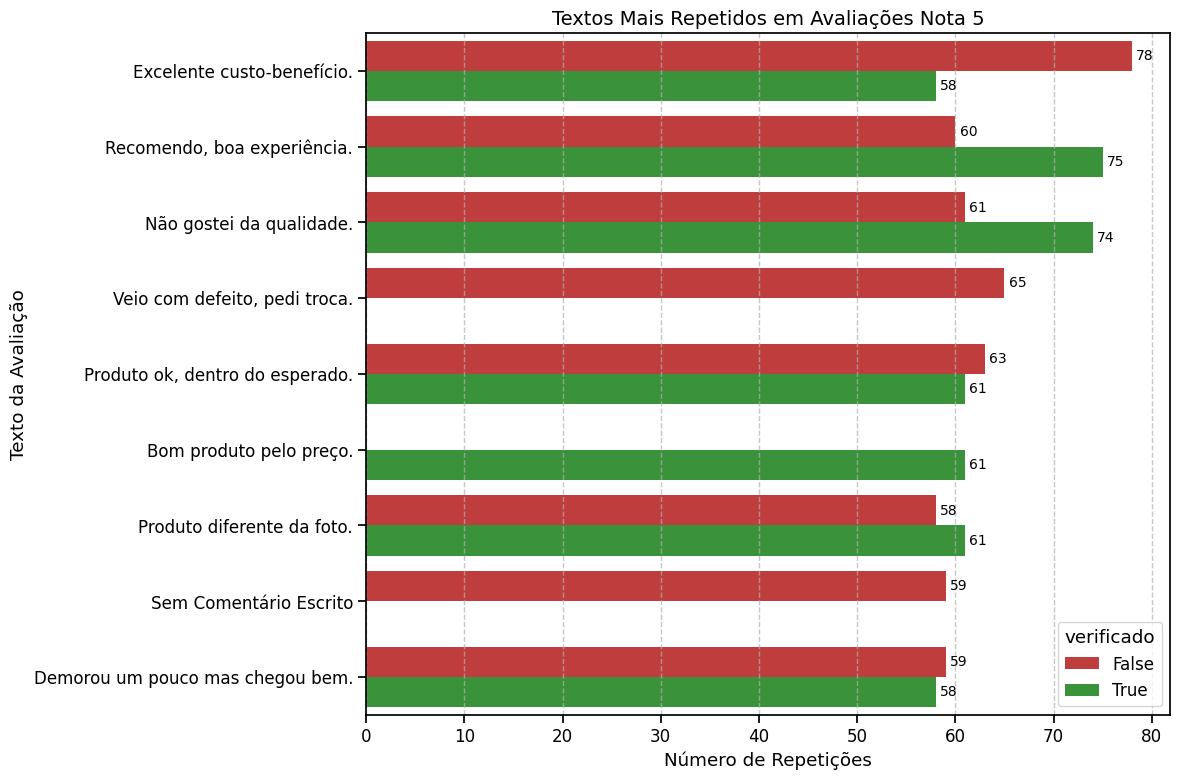

In [110]:
df_textos = df_nota_5.groupby(
    ['texto_avaliacao', 'verificado'],
    dropna=False
).size().reset_index(name='contagem')

top_textos = df_textos.sort_values('contagem', ascending=False).head(15)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_textos,
    x='contagem',
    y='texto_avaliacao',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)


for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Textos Mais Repetidos em Avaliações Nota 5', fontsize=14)
plt.xlabel('Número de Repetições')
plt.ylabel('Texto da Avaliação')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

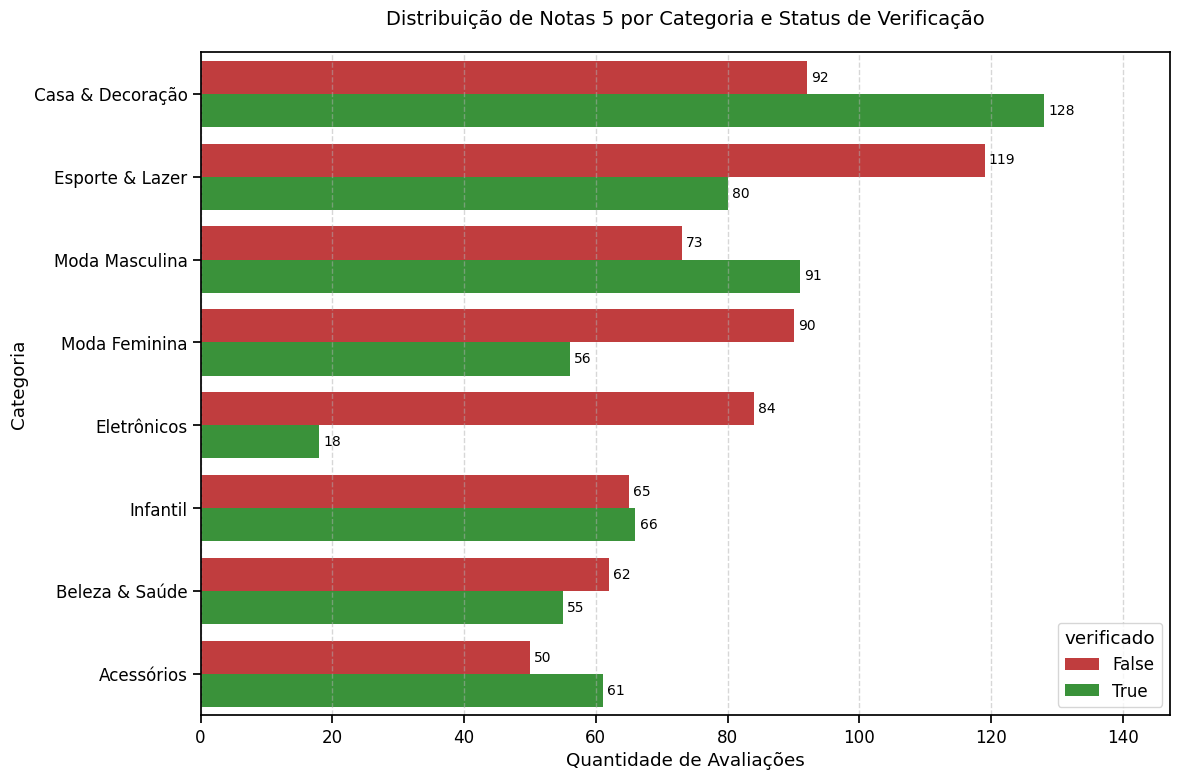

In [111]:
df_categorias = df_nota_5.groupby(
    ['categoria_principal', 'verificado']
).size().reset_index(name='contagem')

df_categorias = df_categorias.sort_values('contagem', ascending=False)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_categorias,
    x='contagem',
    y='categoria_principal',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'} 
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Distribuição de Notas 5 por Categoria e Status de Verificação', fontsize=14, pad=20)
plt.xlabel('Quantidade de Avaliações')
plt.ylabel('Categoria')

plt.xlim(0, df_categorias['contagem'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

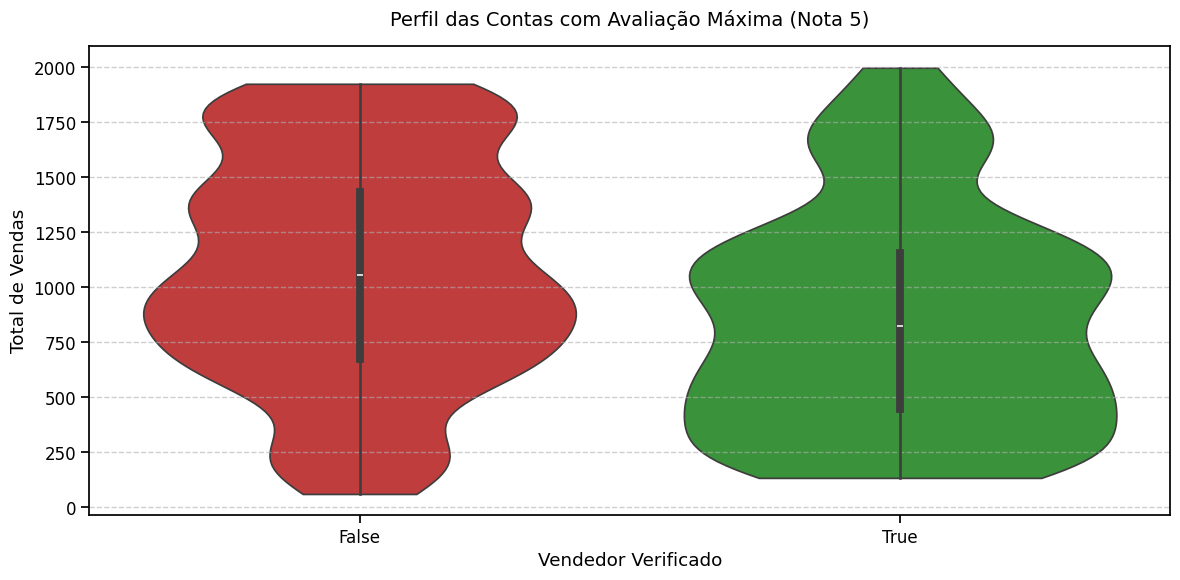

In [112]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_nota_5, 
    x='verificado',
    y='total_vendas', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylabel('Total de Vendas')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

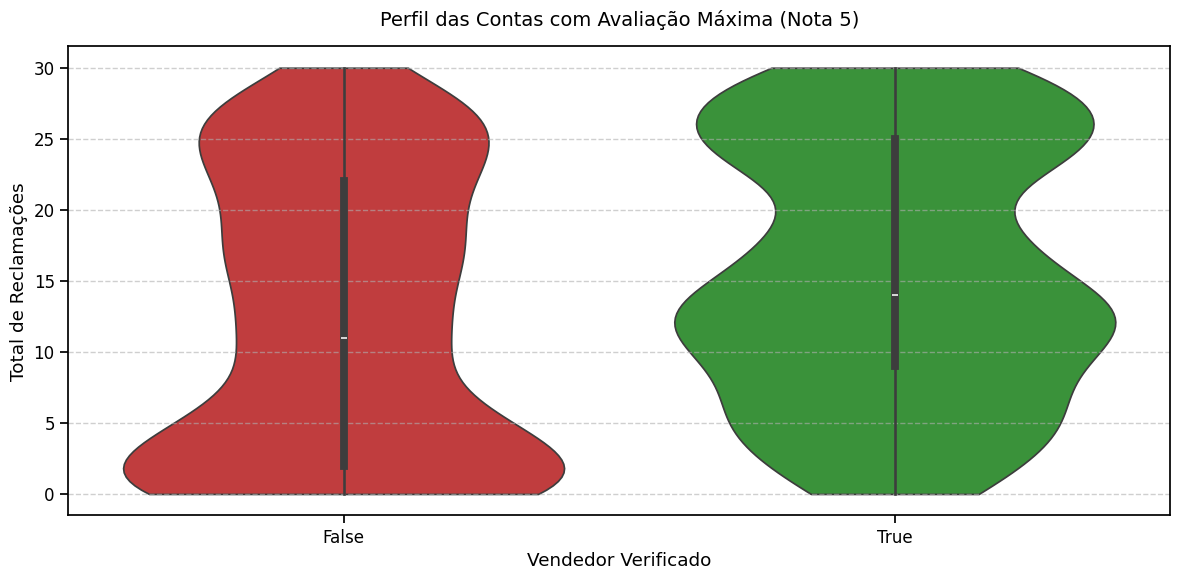

In [113]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_nota_5, 
    x='verificado',
    y='reclamacoes', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylabel('Total de Reclamações')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

**Conclusão:**
- Há uma sazonalidade entre as datas das criações das contas entretanto nada que possa indicar um padrão de período como Natal, férias ou Black friday como evento importante (Necessário observar em caso de alterações nos próximos períodos)

---
### 3. **Os vendedores suspeitos compartilham características em comum?**
### 6. **Construa um "score de risco"** baseado nos indicadores encontrados. Quais critérios compõem esse score?

**Conclusão:**
- Ter nota 5 com pouco tempo de criação da conta
- Verificar mesmo ip se repetindo mais de um vendedor (possivelmente uma mesma rede ou sub-rede)
- Verificar Número de reclamações para uma nota 5

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de Pesos (Ajuste aqui)
PESOS_RISCO = {
    'nao_verificado': 1,
    'nota_alta_recente': 3,
    'ip_multi_nota_alta': 4,
    'conflito_reclamacao': 2
}

# 1. Flags Básicas
df_aval_sus_info['flag_nao_verificado'] = np.where(df_aval_sus_info['verificado'] == False, 1, 0)

# 2. Idade da Conta
df_aval_sus_info['data_criacao_conta'] = pd.to_datetime(df_aval_sus_info['data_criacao_conta'])
df_aval_sus_info['data_avaliacao'] = pd.to_datetime(df_aval_sus_info['data_avaliacao'])
df_aval_sus_info['dias_conta'] = (df_aval_sus_info['data_avaliacao'] - df_aval_sus_info['data_criacao_conta']).dt.days

df_aval_sus_info['flag_nota_alta_recente'] = np.where(
    (df_aval_sus_info['nota'] == 5) & (df_aval_sus_info['dias_conta'] <= 30), 1, 0
)

# 3. Análise de IP (Refinada para focar em IPs com múltiplas avaliações nota 5)
df_nota_5 = df_aval_sus_info[df_aval_sus_info['nota'] == 5]
ips_suspeitos = df_nota_5['ip_origem'].value_counts()
ips_suspeitos = ips_suspeitos[ips_suspeitos > 1].index

df_aval_sus_info['flag_ip_multi_nota_alta'] = np.where(
    df_aval_sus_info['ip_origem'].isin(ips_suspeitos) & (df_aval_sus_info['nota'] == 5), 1, 0
)

# 4. Conflito de Sentimento
df_aval_sus_info['flag_conflito_reclamacao_nota'] = np.where(
    (df_aval_sus_info['reclamacoes'] > 10) & (df_aval_sus_info['nota'] == 5), 1, 0
)

# 5. Cálculo do Score de Risco
df_aval_sus_info['score_risco'] = (
    (df_aval_sus_info['flag_nao_verificado'] * PESOS_RISCO['nao_verificado']) +
    (df_aval_sus_info['flag_nota_alta_recente'] * PESOS_RISCO['nota_alta_recente']) +
    (df_aval_sus_info['flag_ip_multi_nota_alta'] * PESOS_RISCO['ip_multi_nota_alta']) +
    (df_aval_sus_info['flag_conflito_reclamacao_nota'] * PESOS_RISCO['conflito_reclamacao'])
)

In [119]:
ranking_vendedores = df_aval_sus_info.groupby(['vendedor_id']).agg({
    'score_risco': 'mean',
    'avaliacao_id': 'count'
}).rename(columns={'avaliacao_id': 'qtd_avaliacoes_analisadas'}).reset_index()

ranking_vendedores.sort_values('score_risco', ascending=False)['score_risco'].describe()

vendedores_suspeitos_lista = ranking_vendedores[ranking_vendedores['score_risco'] >= 3].sort_values(by='score_risco', ascending=False)

print("Lista de Vendedores Suspeitos para Auditoria:")
print(vendedores_suspeitos_lista)

Lista de Vendedores Suspeitos para Auditoria:
   vendedor_id  score_risco  qtd_avaliacoes_analisadas
45   VEND-0046         6.67                         21
44   VEND-0045         5.43                         30
42   VEND-0043         5.43                         30
41   VEND-0042         4.85                         20
43   VEND-0044         4.50                         28


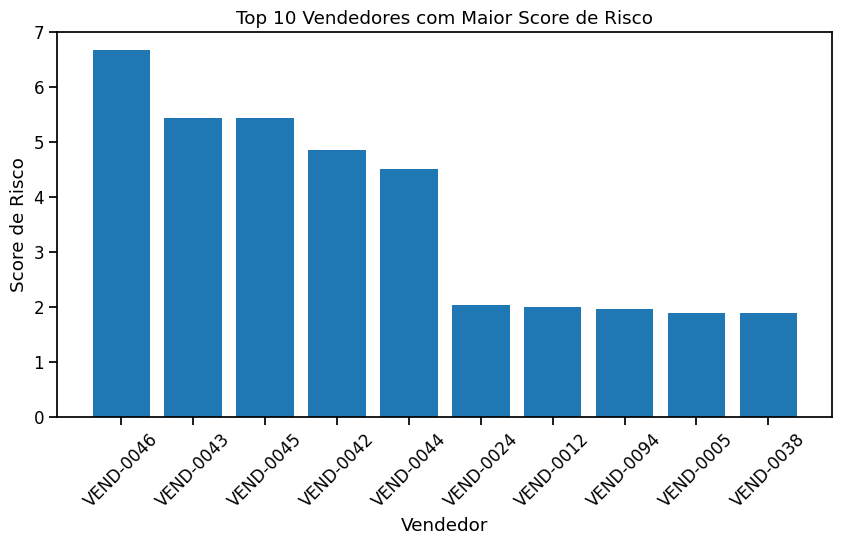

In [120]:
top_risco = ranking_vendedores.sort_values('score_risco', ascending=False).head(10)

plt.bar(top_risco['vendedor_id'].astype(str), top_risco['score_risco'])
plt.xlabel('Vendedor')
plt.ylabel('Score de Risco')
plt.title('Top 10 Vendedores com Maior Score de Risco')
plt.xticks(rotation=45)
plt.show()

---
### 4. **Qual o impacto financeiro** das vendas dos vendedores suspeitos? Quanto representam do faturamento total?

In [121]:
suspeitos = vendedores_suspeitos_lista['vendedor_id']

percentual = (
    df_vendedor.loc[df_vendedor['vendedor_id'].isin(suspeitos), 'total_vendas'].sum()
    / df_vendedor['total_vendas'].sum()
) * 100

percentual_faturamento_suspeitos = (
    df_vendas_final.loc[df_vendas_final['vendedor_id'].isin(suspeitos), 'valor_total'].sum() 
    / df_vendas_final['valor_total'].sum()
) * 100

print(f'{df_vendedor.loc[df_vendedor['vendedor_id'].isin(suspeitos), 'total_vendas'].sum():.2f} Vendas de vendedores suspeitos: {percentual:.2f}% do total')
print(f'Faturamento de ${df_vendas_final.loc[df_vendas_final['vendedor_id'].isin(suspeitos), 'valor_total'].sum():.2f} Vendedores suspeitos representam {percentual_faturamento_suspeitos:.2f}% do faturamento total.')

5829.00 Vendas de vendedores suspeitos: 5.09% do total
Faturamento de $51816.25 Vendedores suspeitos representam 4.04% do faturamento total.


**Conclusão:**


* Vendedores suspeitos representam 7,97% das vendas e 6,09% do faturamento total.
* No momento não é tão significativo, mas  necessário não dar abertura para um maior desenvolvimento dessa representação

---
###  5. **A taxa de cancelamento/devolução** dos vendedores suspeitos é diferente dos demais?

In [122]:
# Contagem de status
vendas_total = df_vendas_final['status_pedido'].value_counts()
vendas_susp = df_vendas_final.loc[
    df_vendas_final['vendedor_id'].isin(suspeitos), 
    'status_pedido'
].value_counts()

# Criar dataframe comparativo
df_taxa_cancelamento = (
    pd.DataFrame({
        'total_geral': vendas_total,
        'vendedores_suspeitos': vendas_susp
    })
    .fillna(0)
)

# Calcular taxas
df_taxa_cancelamento['taxa_total_%'] = (
    df_taxa_cancelamento['total_geral'] / df_taxa_cancelamento['total_geral'].sum()
) * 100

df_taxa_cancelamento['taxa_suspeitos_%'] = (
    df_taxa_cancelamento['vendedores_suspeitos'] / df_taxa_cancelamento['vendedores_suspeitos'].sum()
) * 100

df_taxa_cancelamento = df_taxa_cancelamento.reset_index().rename(columns={'index':'status_pedido'})
df_taxa_cancelamento

,status_pedido,total_geral,vendedores_suspeitos,taxa_total_%,taxa_suspeitos_%
0,Cancelado,878,25,12.36,8.77
1,Devolvido,868,35,12.22,12.28
2,Em trânsito,901,33,12.68,11.58
3,Entregue,4458,192,62.74,67.37


**Conclusão:**

- A maioria dos pedidos é entregue: cerca de 62,7% no total e 67,5% entre vendedores suspeitos.

- A taxa de cancelamento é menor entre vendedores suspeitos (9,05%) em comparação ao total da plataforma (12,36%).

- A taxa de devolução é semelhante entre os dois grupos (11,37% suspeitos vs. 12,22% geral).

- O comportamento geral dos vendedores suspeitos é parecido com o padrão da plataforma, sem aumento evidente em cancelamentos ou devoluções.

---

### 7. Regras Automáticas para Identificação de Vendedores e Vendas Suspeitas

As regras abaixo utilizam o **Score de Risco** calculado e o comportamento transacional para sinalizar contas que exigem moderação humana ou bloqueio preventivo.


#### 1. Regra de Explosão de Reputação (Shilling)

* **Gatilho:** Vendedor com conta criada há menos de 30 dias que recebe mais de 5 avaliações "Nota 5" em um intervalo de 24 horas vindas de usuários "Não Verificados".
* **Lógica:** Identifica a tentativa de inflar artificialmente a reputação de uma loja nova para passar credibilidade antes de aplicar golpes.

#### 2. Regra de Concentração de Rede (IP Cluster)

* **Gatilho:** Múltiplas vendas ou avaliações (mais de 3) originadas do endereço IP identificado na `flag_ip_multi_nota_alta` para o mesmo vendedor.
* **Lógica:** Se o mesmo endereço de rede gera múltiplas notas máximas para um único vendedor, há uma altíssima probabilidade de autocompra ou uso de fazendas de cliques.

#### 3. Regra de Inconsistência de Satisfação (Conflito de Feedback)

* **Gatilho:** Vendas que possuem `flag_conflito_reclamacao_nota` ativo, onde o vendedor mantém nota alta apesar de um volume de reclamações superior a 15% do total de vendas.
* **Lógica:** Sinaliza vendedores que podem estar manipulando o sistema de avaliações para esconder problemas graves de operação ou envio de produtos falsos.

#### 4. Regra de Retenção de Score Crítico

* **Gatilho:** Acúmulo de uma média de `score_risco` por vendedor superior a 7 (em uma escala de 0 a 10) nas últimas 20 transações.
* **Lógica:** Um filtro de segurança de "massa crítica". Quando o comportamento suspeito não é isolado em uma única venda, mas sim um padrão em todo o histórico recente do vendedor.

#### 5. Regra de Transação de Curto Ciclo

* **Gatilho:** Venda realizada e avaliada com Nota 5 em um tempo inferior ao prazo mínimo de entrega logística da região (ex: avaliação no mesmo dia da compra).
* **Lógica:** Se o produto não teve tempo físico de chegar ao comprador e já recebeu nota máxima, a transação é provavelmente fictícia para lavagem de dinheiro ou inflação de ranking.